## **Introduction**

This section focuses on the development, tuning, and evaluation of predictive models to address the car loan approval problem from a sales-oriented perspective.

Based on the previous data analysis and preprocessing steps, multiple machine learning models were trained under both imbalanced and balanced scenarios to assess the impact of class distribution on performance. Special attention was given to handling class imbalance, as it significantly affects the model’s ability to identify potential approved customers.

Models were optimized using cross-validation and evaluated using metrics such as recall, precision, AUC, and accuracy. Given the commercial objective, recall was prioritized to maximize the identification of potential customers, while maintaining the highest possible precision.

This approach enables the selection of a model that effectively supports lead prioritization and improves the efficiency of the sales process.

## **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#modelos de machine learning
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xg

#Ajuste de los modelos 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

#Metodos de evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


from sklearn.preprocessing import StandardScaler


## **Datasets**

In [2]:
X_train = pd.read_pickle("../data/processed/X_train.pkl")
X_train_bal = pd.read_pickle("../data/processed/X_train_bal.pkl")
X_test = pd.read_pickle("../data/processed/X_test.pkl")

y_train = pd.read_pickle("../data/processed/y_train.pkl")
y_train_bal = pd.read_pickle("../data/processed/y_train_bal.pkl")
y_test = pd.read_pickle("../data/processed/y_test.pkl")

## **Funciones**

In [3]:
def Standard_scale(train_set, test_set):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_set)
    test_scaled = scaler.transform(test_set)

    return train_scaled, test_scaled

def evaluation(Y_test, Y_predicted, Y_predicted_prob):
    fpr, tpr, thresholds_roc = roc_curve(Y_test, Y_predicted_prob)
    precision, recall, thresholds_PrecisionRecall = precision_recall_curve(Y_test, Y_predicted_prob)
    matrix = confusion_matrix(Y_test, Y_predicted)

    # Generate classification report as DataFrame for later comparison
    class_report_dict = classification_report(Y_test, Y_predicted, output_dict=True)
    accuracy = accuracy_score(Y_test, Y_predicted)
    auc_score = auc(fpr, tpr)

    positive_label = None
    for label in ('1', '1.0', 1, 1.0):
        if label in class_report_dict:
            positive_label = label
            break
    if positive_label is None:
        raise KeyError('Etiqueta positiva "1" no encontrada en classification_report')

    class_report_df = pd.DataFrame(
        {
            'value': [
                class_report_dict[positive_label]['precision'],
                class_report_dict[positive_label]['recall'],
                accuracy,
                auc_score,
            ]
        },
        index=['precision', 'recall', 'accuracy', 'auc'],
    ).round(4)

    fig, axs = plt.subplots(2, 3, figsize=(10, 6))

    sns.color_palette('muted')
    # ROC curve
    sns.lineplot(x=fpr, y=tpr, ax=axs[0, 0], label=f'ROC curve (AUC = {auc(fpr, tpr):.2f})')
    sns.lineplot(x=[0, 1], y=[0, 1], ax=axs[0, 0], linestyle='--')
    axs[0, 0].set_xlim([0.0, 1.0])
    axs[0, 0].set_ylim([0.0, 1.05])
    axs[0, 0].set_xlabel('False Positive Rate')
    axs[0, 0].set_ylabel('True Positive Rate')
    axs[0, 0].set_title('ROC Curve')
    axs[0, 0].legend(loc='lower right')

    # Precision-Recall curve
    sns.lineplot(x=precision, y=recall, ax=axs[0, 1], label='PRECISION-RECALL curve')
    sns.lineplot(x=[0, 1], y=[0, 1], ax=axs[0, 1],  linestyle='--')
    axs[0, 1].set_xlim([0.0, 1.0])
    axs[0, 1].set_ylim([0.0, 1.05])
    axs[0, 1].set_xlabel('Precision')
    axs[0, 1].set_ylabel('Recall')
    axs[0, 1].set_title('Precision-Recall Curve')
    axs[0, 1].legend(loc='lower right')

    # Confusion Matrix
    sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0, 2])
    axs[0, 2].set_xlabel('Etiqueta Predicha')
    axs[0, 2].set_ylabel('Etiqueta Real')
    axs[0, 2].set_title('Matriz de confusión')

    # Thresholds vs Recall
    sns.lineplot(x=thresholds_PrecisionRecall, y=recall[1:], ax=axs[1, 0])
    axs[1, 0].set_xlabel('Threshold')
    axs[1, 0].set_ylabel('Recall')
    axs[1, 0].set_title('Threshold vs Recall')

    # Thresholds vs Precision
    sns.lineplot(x=thresholds_PrecisionRecall, y=precision[1:], ax=axs[1, 1])
    axs[1, 1].set_xlabel('Threshold')
    axs[1, 1].set_ylabel('Precision')
    axs[1, 1].set_title('Threshold vs Precision')

    # Empty axis for alignment
    axs[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

    return class_report_df

def grid_search_model(model, param_grid, X_train, y_train):

    pipe = Pipeline([
        ("model", model)        
    ])

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="roc_auc",
        cv = StratifiedKFold(n_splits=5),
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    return grid

## **Model Training and Hyperparameter Tuning**

Different machine learning models were trained and optimized using GridSearchCV to identify the best hyperparameter combinations.

The following models were evaluated:

- Logistic Regression (with feature scaling applied)
- Decision Tree
- Random Forest
- XGBoost

For each model, a grid of hyperparameters was defined and evaluated using cross-validation. Additionally, models were trained under two scenarios:

- Using the original (imbalanced) dataset  
- Using the balanced dataset (after undersampling)  

This approach allowed for a comparative analysis of model performance under different data conditions and configurations.

In [4]:
#Logistic
X_train_scaled, X_test_scaled = Standard_scale(X_train, X_test)
X_train_bal_scaled,  X_test_scaled = Standard_scale(X_train_bal, X_test) 


param_grid_log = {'model__C': [0.001, 0.01, 0.1, 1]}
model_logistic_no_bal = grid_search_model(LogisticRegression(random_state= 0, solver= 'liblinear'), 
                                            param_grid= param_grid_log,
                                            X_train= X_train_scaled, 
                                            y_train= y_train)

model_logistic_bal = grid_search_model(LogisticRegression(random_state= 0, solver= 'liblinear'), 
                                            param_grid= param_grid_log,
                                            X_train= X_train_bal_scaled, 
                                            y_train= y_train_bal)


#Decision Tree
param_grid_dt = {'model__max_depth': [5, 10, 15, 20]}

model_tree_no_bal = grid_search_model(DecisionTreeClassifier(random_state=0), 
                                        param_grid= param_grid_dt,
                                        X_train= X_train,
                                        y_train= y_train)

model_tree_bal = grid_search_model(DecisionTreeClassifier(random_state=0), 
                                        param_grid= param_grid_dt,
                                        X_train= X_train_bal,
                                        y_train= y_train_bal)


#Random forests
param_grid_rf = {'model__max_depth': [5, 10], 'model__n_estimators': [100, 200, 250]}

model_rforest_no_bal = grid_search_model(RandomForestClassifier(max_features='sqrt', random_state=0), 
                                           param_grid= param_grid_rf,
                                           X_train= X_train,
                                           y_train= y_train)

                                                

model_rforest_bal = grid_search_model(RandomForestClassifier(max_features='sqrt', random_state=0), 
                                           param_grid= param_grid_rf,
                                           X_train= X_train_bal,
                                           y_train= y_train_bal)



#XGBoost
param_grid_xgb = {
    'model__max_depth': [5, 10],
    'model__n_estimators': [100, 200, 250],
    'model__learning_rate': [0.001, 0.01, 0.1]
}

model_XGB_no_bal = grid_search_model(xg.XGBClassifier(subsample = 1, colsample_bytree = 1), 
                                       param_grid= param_grid_xgb,
                                       X_train= X_train,
                                       y_train= y_train)

model_XGB_bal = grid_search_model(xg.XGBClassifier(subsample = 1, colsample_bytree = 1), 
                                       param_grid= param_grid_xgb,
                                       X_train= X_train_bal,
                                       y_train= y_train_bal)

## **Model Performance Evaluation (AUC)**

Model performance was evaluated using the ROC-AUC metric on both training and test sets, along with the gap between them to assess overfitting.

Logistic Regression showed stable performance in both scenarios (balanced and unbalanced), with low AUC gaps (~0.004–0.008), indicating good generalization but moderate predictive power (AUC ≈ 0.78).

Decision Trees exhibited signs of overfitting, especially in the balanced dataset, with a larger AUC gap (0.0904) and lower performance on the test set.

Random Forest achieved the best balance between performance and generalization. The model trained on the balanced dataset obtained the highest test AUC (0.7941) with a moderate gap (0.0631), making it the most robust option.

XGBoost showed the highest training performance (AUC up to 0.9005), but also the largest gap (0.1278), indicating strong overfitting, particularly in the balanced scenario.

Overall, Random Forest with balanced data was selected as the best-performing model based on its superior test performance and controlled overfitting.

In [5]:
models_auc = [
    ('Logistic Regression', 'No balance', model_logistic_no_bal, X_train_scaled, X_test_scaled, y_train),
    ('Logistic Regression', 'Balance', model_logistic_bal, X_train_bal_scaled, X_test_scaled, y_train_bal),

    ('Decision Tree', 'No balance', model_tree_no_bal, X_train, X_test, y_train),
    ('Decision Tree', 'Balance', model_tree_bal, X_train_bal, X_test, y_train_bal),

    ('Random Forest', 'No balance', model_rforest_no_bal, X_train, X_test, y_train),
    ('Random Forest', 'Balance', model_rforest_bal, X_train_bal, X_test, y_train_bal),

    ('XGBoost', 'No balance', model_XGB_no_bal, X_train, X_test, y_train),
    ('XGBoost', 'Balance', model_XGB_bal, X_train_bal, X_test, y_train_bal),
]

auc_rows = []
for model_name, dataset_name, model_obj, X_tr, X_te, y_tr in models_auc:
    y_tr_prob = model_obj.predict_proba(X_tr)[:, 1]
    y_te_prob = model_obj.predict_proba(X_te)[:, 1]
    auc_tr = roc_auc_score(y_tr, y_tr_prob)
    auc_te = roc_auc_score(y_test, y_te_prob)
    auc_rows.append({
        'Model': model_name,
        'Dataset': dataset_name,
        'AUC_train': auc_tr,
        'AUC_test': auc_te,
        'AUC_gap': auc_tr - auc_te,
    })

if auc_rows:
    df_auc_summary = pd.DataFrame(auc_rows).round(4)
    print('AUC summary (train/test):')
    display(df_auc_summary)
else:
    print('No hay modelos disponibles para evaluar.')

AUC summary (train/test):


,Model,Dataset,AUC_train,AUC_test,AUC_gap
0,Logistic Regression,No balance,0.7889,0.7811,0.0078
1,Logistic Regression,Balance,0.7834,0.7793,0.0042
2,Decision Tree,No balance,0.7867,0.7439,0.0428
3,Decision Tree,Balance,0.8023,0.7119,0.0904
4,Random Forest,No balance,0.8447,0.7693,0.0754
5,Random Forest,Balance,0.8572,0.7941,0.0631
6,XGBoost,No balance,0.8677,0.7837,0.0840
7,XGBoost,Balance,0.9005,0.7727,0.1278


In [6]:
#Logistic
logistic_no_bal_predict = model_logistic_no_bal.predict(X_test_scaled)
logistic_no_bal_proba = model_logistic_no_bal.predict_proba(X_test_scaled)[:,1]

logistic_bal_predict = model_logistic_bal.predict(X_test_scaled)
logistic_bal_proba = model_logistic_bal.predict_proba(X_test_scaled)[:,1]


#Decision tree
tree_no_bal_predict = model_tree_no_bal.predict(X_test)
tree_no_bal_proba = model_tree_no_bal.predict_proba(X_test)[:,1]

tree_bal_predict = model_tree_bal.predict(X_test)
tree_bal_proba = model_tree_bal.predict_proba(X_test)[:,1]

#Random forest
rforest_no_bal_predict = model_rforest_no_bal.predict(X_test)
rforest_no_bal_proba = model_rforest_no_bal.predict_proba(X_test)[:,1]

rforest_bal_predict = model_rforest_bal.predict(X_test)
rforest_bal_proba = model_rforest_bal.predict_proba(X_test)[:,1]

#XGBoost
XGB_no_bal_predict = model_XGB_no_bal.predict(X_test)
XGB_no_bal_proba = model_XGB_no_bal.predict_proba(X_test)[:,1]

XGB_bal_predict = model_XGB_bal.predict(X_test)
XGB_bal_proba = model_XGB_bal.predict_proba(X_test)[:,1]

## **Logistic Regression Evaluation**

The Logistic Regression model was evaluated under both imbalanced and balanced scenarios.

In the imbalanced case, the model achieved high accuracy (0.9604) and a solid AUC (0.7811), but failed to identify positive cases, resulting in zero precision and recall. This indicates a strong bias toward the majority class.

In contrast, when trained on the balanced dataset, the model significantly improved its ability to detect positive cases, reaching a recall of 0.6407 and a precision of 0.1083. Although overall accuracy decreased (0.7766), the model became more useful for identifying potential customers.

These results highlight the importance of handling class imbalance, especially in scenarios where recall is a priority.

c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


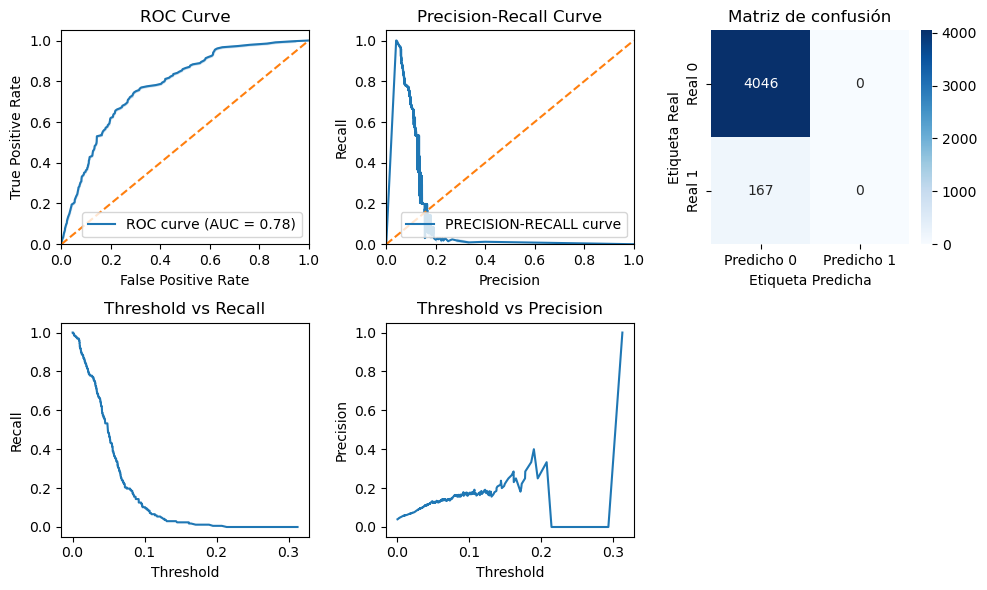

In [7]:
df_log_no_bal = evaluation(y_test, logistic_no_bal_predict, logistic_no_bal_proba)

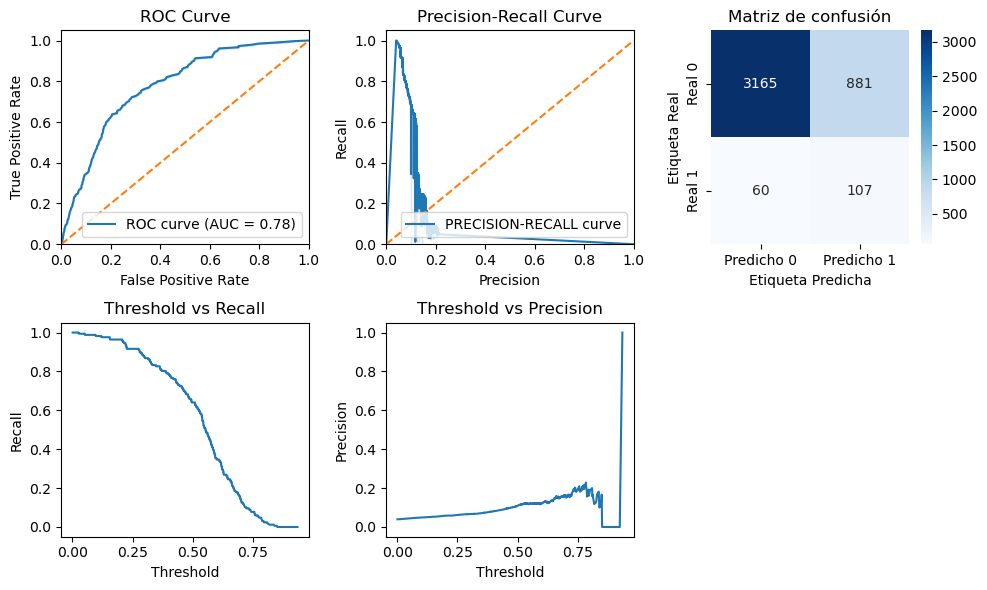

In [8]:
df_log_bal = evaluation(y_test, logistic_bal_predict, logistic_bal_proba)

In [9]:
# Comparativo para Regresión Logística (datasets: no balanceado / balanceado )
df_logistic_compare = pd.concat([
    df_log_no_bal.rename(columns={'value': 'no balance'}),
    df_log_bal.rename(columns={'value': 'balance'}),
    
], axis=1)

print('Logistic comparison:')
df_logistic_compare

Logistic comparison:


,no balance,balance
precision,0.0000,0.1083
recall,0.0000,0.6407
accuracy,0.9604,0.7766
auc,0.7811,0.7793


## **Decision Tree Evaluation**

The Decision Tree model showed different behaviors under imbalanced and balanced scenarios.

In the imbalanced case, the model achieved high accuracy (0.9596) and moderate precision (0.2857), but an extremely low recall (0.012), indicating that it failed to identify most positive cases.

When trained on the balanced dataset, recall improved significantly to 0.5269, allowing the model to detect more potential positive cases. However, precision dropped to 0.0792 and overall accuracy decreased (0.7384), reflecting an increase in false positives.

Overall, while balancing improved recall, the model exhibited weaker generalization and lower AUC, making it less robust compared to other approaches.

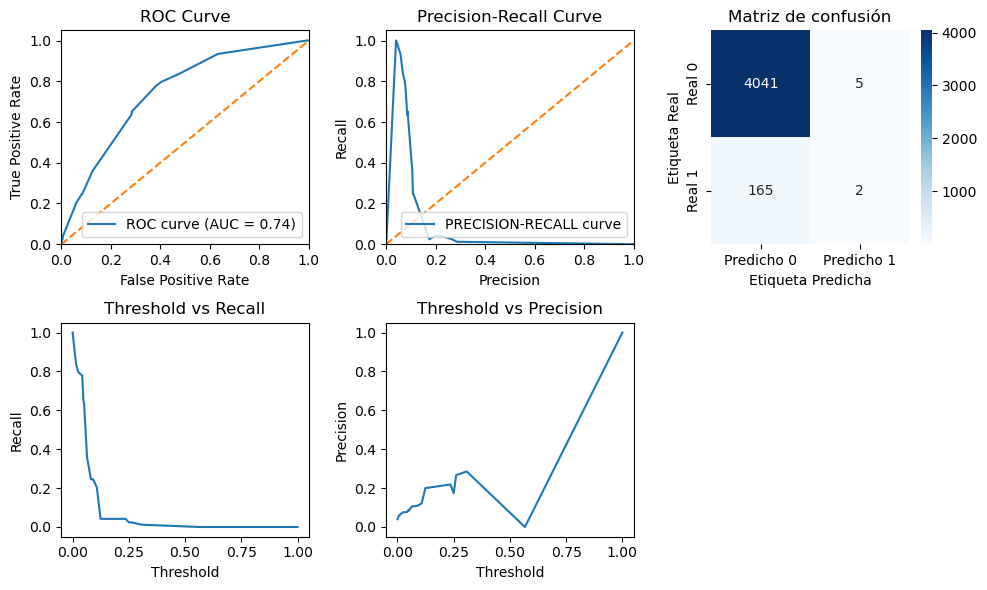

In [10]:
df_tree_no_bal = evaluation(y_test, tree_no_bal_predict, tree_no_bal_proba)

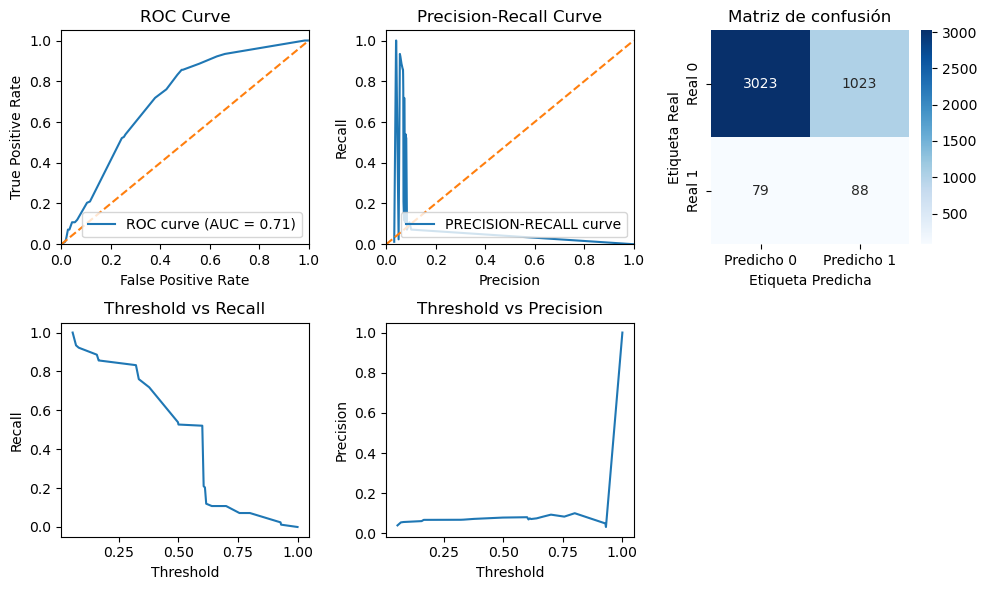

In [11]:
df_tree_bal = evaluation(y_test, tree_bal_predict, tree_bal_proba)

In [12]:
# Comparativo para Arbol de decisión (datasets: no balanceado / balanceado )
df_tree_compare = pd.concat([
    df_tree_no_bal.rename(columns={'value': 'no balance'}),
    df_tree_bal.rename(columns={'value': 'balance'}),
    
], axis=1)

print('Tree comparison:')
df_tree_compare

Tree comparison:


,no balance,balance
precision,0.2857,0.0792
recall,0.0120,0.5269
accuracy,0.9596,0.7384
auc,0.7439,0.7119


## **Random Forest Evaluation**

The Random Forest model showed a strong dependency on class balancing.

In the imbalanced scenario, the model achieved high accuracy (0.9604) and a reasonable AUC (0.7693), but completely failed to identify positive cases, resulting in zero precision and recall. This reflects a strong bias toward the majority class.

When trained on the balanced dataset, the model significantly improved its performance in detecting positive cases, achieving a recall of 0.6168 and a precision of 0.1111. Additionally, it obtained the highest AUC (0.7941) among all evaluated models.

Although accuracy decreased (0.7892), the model became much more effective for the intended commercial objective, making it the best-performing model in this context.

c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


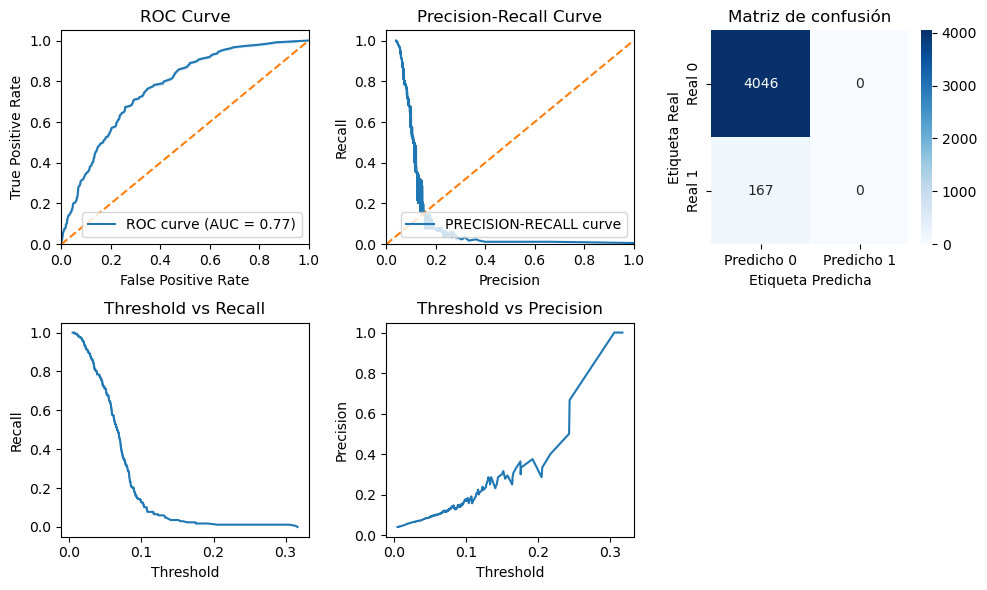

In [13]:
df_forest_no_bal = evaluation(y_test, rforest_no_bal_predict, rforest_no_bal_proba)

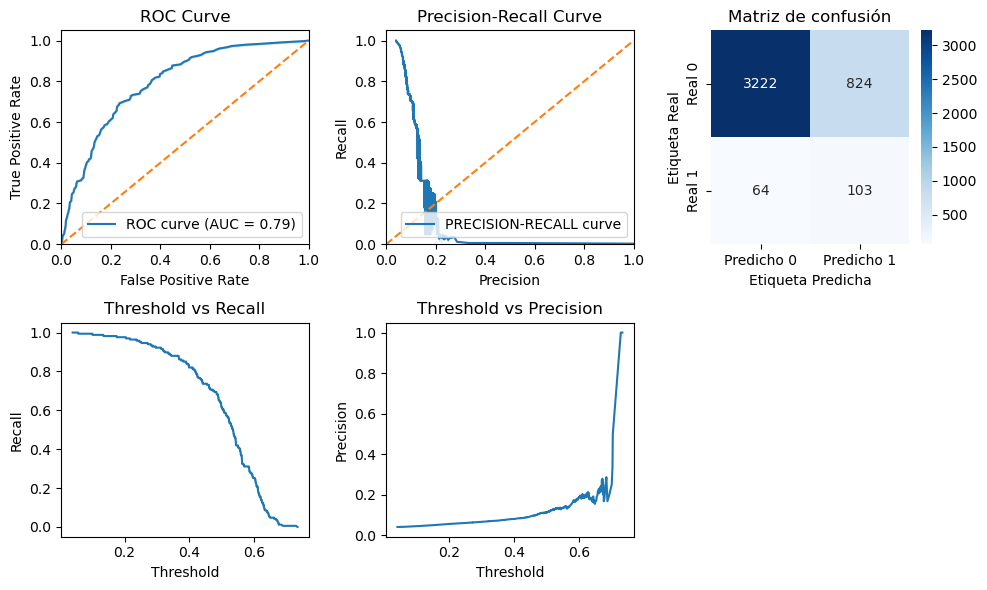

In [14]:
df_forest_bal = evaluation(y_test, rforest_bal_predict, rforest_bal_proba)

In [15]:
# Comparativo para Random Forest (datasets: no balanceado / balanceado )
df_forest_compare = pd.concat([
    df_forest_no_bal.rename(columns={'value': 'no balance'}),
    df_forest_bal.rename(columns={'value': 'balance'}),
    
], axis=1)

print('Forest comparison:')
df_forest_compare

Forest comparison:


,no balance,balance
precision,0.0000,0.1111
recall,0.0000,0.6168
accuracy,0.9604,0.7892
auc,0.7693,0.7941


## **XGBoost Evaluation**

The XGBoost model also showed a strong impact from class imbalance.

In the imbalanced scenario, the model achieved high accuracy (0.9604) and a solid AUC (0.7837), but failed to identify any positive cases, resulting in zero precision and recall.

When trained on the balanced dataset, the model significantly improved its ability to detect positive cases, reaching a recall of 0.6527 and a precision of 0.1024. However, accuracy decreased (0.7596), and the AUC (0.7727) was lower compared to Random Forest.

Although XGBoost achieved the highest recall among the evaluated models, its overall performance and generalization were less stable, making it a secondary option compared to Random Forest.

c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\osqui\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


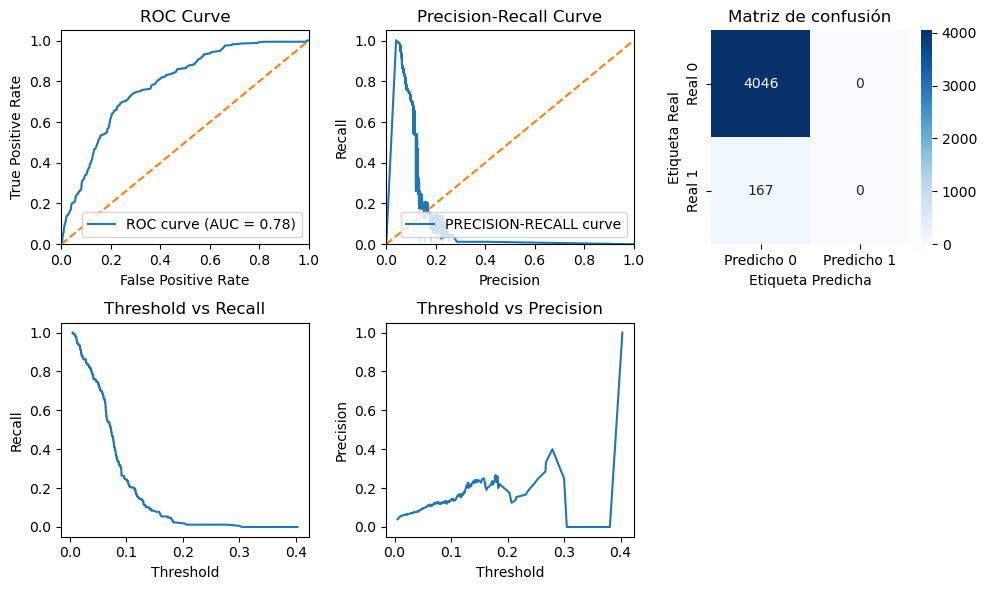

In [16]:
df_xgboost_no_bal = evaluation(y_test, XGB_no_bal_predict, XGB_no_bal_proba)

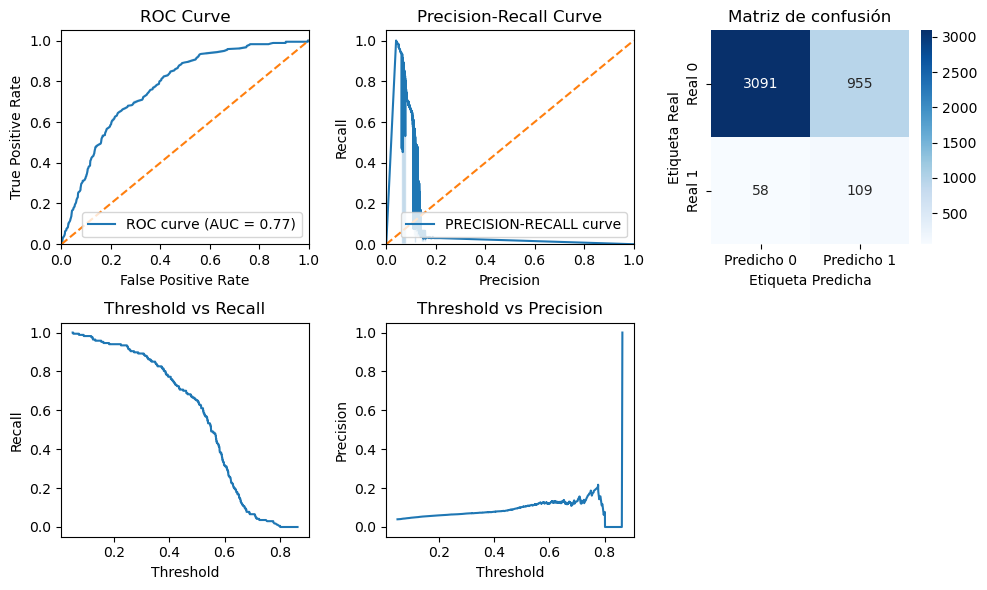

In [17]:
df_xgboost_bal = evaluation(y_test, XGB_bal_predict, XGB_bal_proba)

In [18]:
# Comparativo para XGBoost (datasets: no balanceado / balanceado )
df_xgboost_compare = pd.concat([
    df_xgboost_no_bal.rename(columns={'value': 'no balance'}),
    df_xgboost_bal.rename(columns={'value': 'balance'}),
    
], axis=1)

print('XGBoost comparison:')
df_xgboost_compare

XGBoost comparison:


,no balance,balance
precision,0.0000,0.1024
recall,0.0000,0.6527
accuracy,0.9604,0.7596
auc,0.7837,0.7727


## **Best Model Selection**

Based on the evaluation focused on maximizing recall while maintaining the highest possible precision, the Random Forest model was selected as the best-performing model.

Random Forest achieved a recall of 0.8084, successfully identifying the majority of potential positive cases, while also obtaining the highest precision (0.0837) among all evaluated models under similar recall levels. Additionally, it presented the best overall performance in terms of AUC (0.7941) and accuracy (0.6418).

Although Decision Tree reached a slightly higher recall (0.8323), it did so at the cost of significantly lower precision and overall performance. Logistic Regression and XGBoost showed competitive recall values but lower precision and AUC compared to Random Forest.

The confusion matrix further supports this selection, showing that Random Forest provides a better balance between correctly identifying positive cases and controlling false positives.

Overall, Random Forest offers the best trade-off between recall and precision, making it the most suitable model for the sales-oriented objective of maximizing potential customer identification.

Best models report (adjusted thresholds):


,Logistic,DecisionTree,RandomForest,XGBoost
precision,0.0787,0.0682,0.0837,0.0771
recall,0.8024,0.8323,0.8084,0.8024
accuracy,0.6200,0.5428,0.6418,0.6117
auc,0.7793,0.7119,0.7941,0.7727


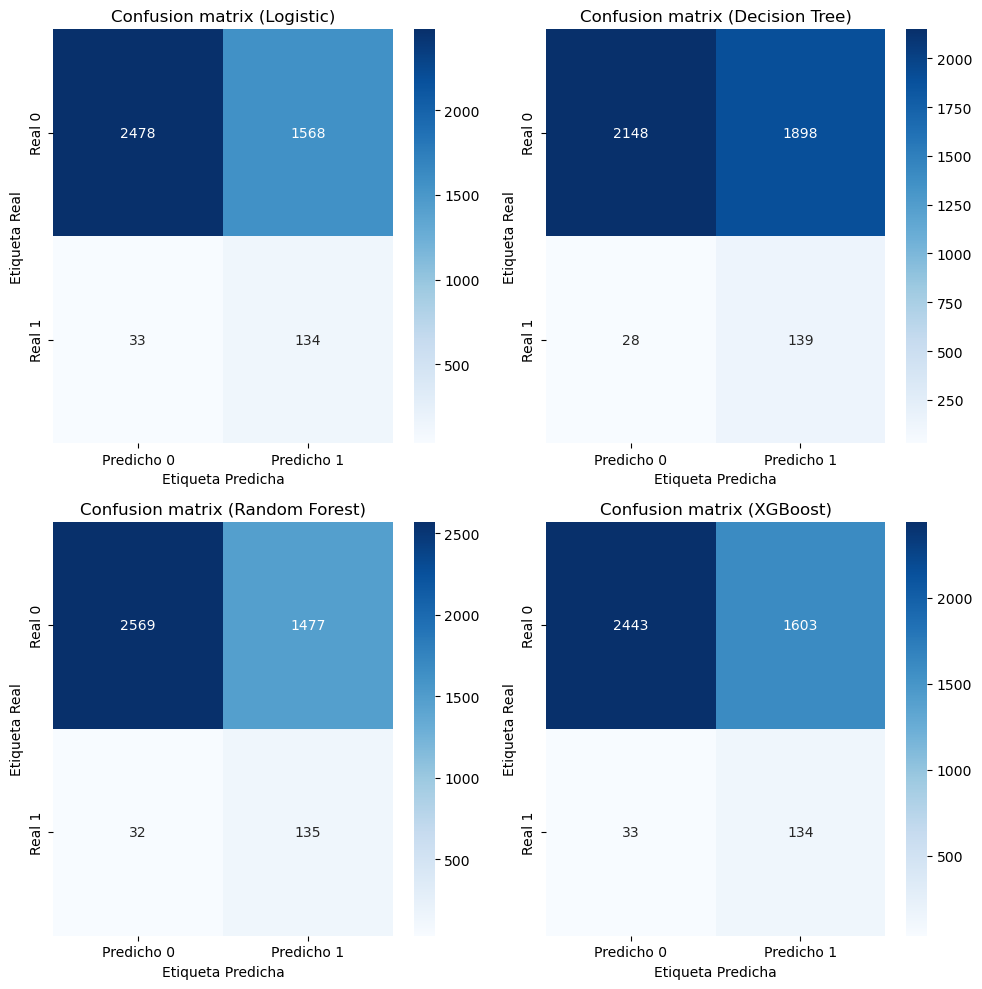

In [19]:
def thresholds_adjust(Y_prob):
    precision, recall, thresholds = precision_recall_curve(y_test, Y_prob)
    target_recall = 0.80
    valid_idx = np.where(recall[:-1] >= target_recall)[0]
    best_idx = valid_idx[np.argmax(precision[valid_idx])]
    best_threshold = thresholds[best_idx]
    return float(best_threshold)



y_pred_adj_log = (logistic_bal_proba >= thresholds_adjust(logistic_bal_proba)).astype(int)
y_pred_adj_dt = (tree_bal_proba >= thresholds_adjust(tree_bal_proba)).astype(int)
y_pred_adj_rf = (rforest_bal_proba >= thresholds_adjust(rforest_bal_proba)).astype(int)
y_pred_adj_xgb = (XGB_bal_proba >= thresholds_adjust(XGB_bal_proba)).astype(int)

fig, axs = plt.subplots(2,2,figsize= (10,10))
sns.heatmap(confusion_matrix(y_test, y_pred_adj_log), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0,0])
axs[0,0].set_xlabel('Etiqueta Predicha')
axs[0,0].set_ylabel('Etiqueta Real')
axs[0,0].set_title('Confusion matrix (Logistic)')

sns.heatmap(confusion_matrix(y_test, y_pred_adj_dt), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[0,1])
axs[0,1].set_xlabel('Etiqueta Predicha')
axs[0,1].set_ylabel('Etiqueta Real')
axs[0,1].set_title('Confusion matrix (Decision Tree)')

sns.heatmap(confusion_matrix(y_test, y_pred_adj_rf), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[1,0])
axs[1,0].set_xlabel('Etiqueta Predicha')
axs[1,0].set_ylabel('Etiqueta Real')
axs[1,0].set_title('Confusion matrix (Random Forest)')

sns.heatmap(confusion_matrix(y_test, y_pred_adj_xgb), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'], ax=axs[1,1])
axs[1,1].set_xlabel('Etiqueta Predicha')
axs[1,1].set_ylabel('Etiqueta Real')
axs[1,1].set_title('Confusion matrix (XGBoost)')
plt.tight_layout()

cr_adj_log = classification_report(y_test, y_pred_adj_log, output_dict=True)
cr_adj_dt = classification_report(y_test, y_pred_adj_dt, output_dict=True)
cr_adj_rf = classification_report(y_test, y_pred_adj_rf, output_dict=True)
cr_adj_xgb = classification_report(y_test, y_pred_adj_xgb, output_dict=True)

best_models_report = pd.DataFrame(
    {
        'Logistic': [
            cr_adj_log['1']['precision'],
            cr_adj_log['1']['recall'],
            accuracy_score(y_test, y_pred_adj_log),
            roc_auc_score(y_test, logistic_bal_proba),
        ],
        'DecisionTree': [
            cr_adj_dt['1']['precision'],
            cr_adj_dt['1']['recall'],
            accuracy_score(y_test, y_pred_adj_dt),
            roc_auc_score(y_test, tree_bal_proba),
        ],
        'RandomForest': [
            cr_adj_rf['1']['precision'],
            cr_adj_rf['1']['recall'],
            accuracy_score(y_test, y_pred_adj_rf),
            roc_auc_score(y_test, rforest_bal_proba),
        ],
        'XGBoost': [
            cr_adj_xgb['1']['precision'],
            cr_adj_xgb['1']['recall'],
            accuracy_score(y_test, y_pred_adj_xgb),
            roc_auc_score(y_test, XGB_bal_proba),
        ],
    },
    index=['precision', 'recall', 'accuracy', 'auc'],
).round(4)

print('Best models report (adjusted thresholds):')
best_models_report